In [68]:
import pandas as pd
import ast
from datasets import load_dataset
import matplotlib.pyplot as plt

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply({lambda x: ast.literal_eval(x) if pd.notna(x) else(x)})

<Axes: xlabel='job_title_short'>

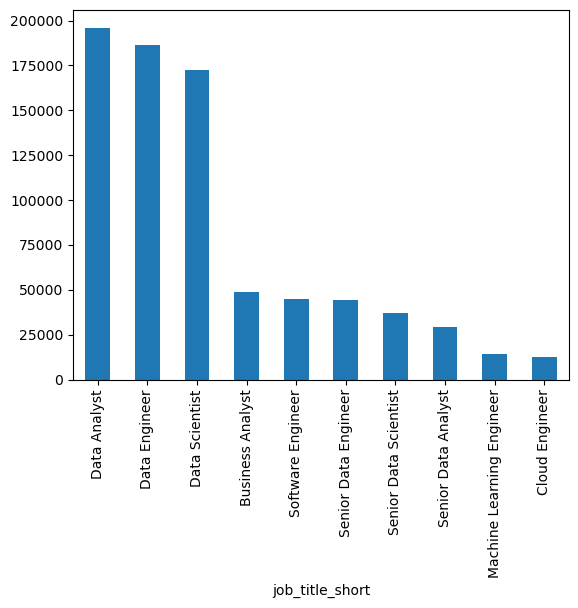

In [69]:
fig, ax = plt.subplots()

df['job_title_short'].value_counts().plot(kind='bar', ax=ax)
#plt.gca().invert_yaxis()

In [70]:
plot1=df['job_title_short'].value_counts().head()


In [71]:
plot2=df['job_schedule_type'].value_counts().head(3)


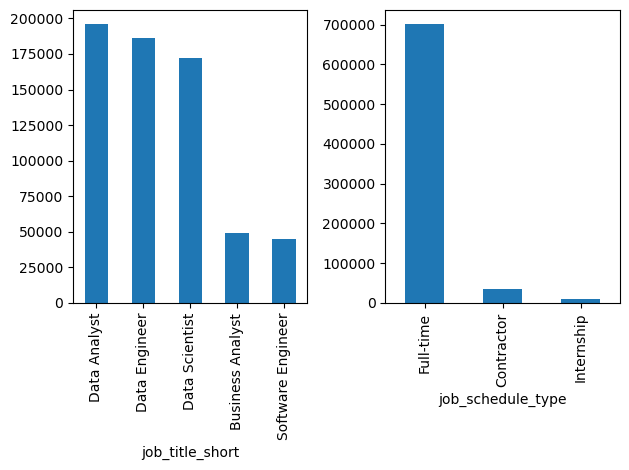

In [72]:
fig,ax = plt.subplots(1,2)

plot1.plot(kind='bar', ax=ax[0])
plot2.plot(kind='bar', ax=ax[1])

fig.tight_layout()

In [73]:
df_skills=df.copy()
df_skills = df_skills.explode('job_skills')
skills_count = df_skills.groupby(['job_skills', 'job_title_short']).size()
df_skills_count = skills_count.reset_index(name='skill_count')
df_skills_count.sort_values(by='skill_count', ascending=False, inplace=True)
df_skills_count

,job_skills,job_title_short,skill_count
1480,python,Data Scientist,113711
1822,sql,Data Engineer,113130
1479,python,Data Engineer,108022
1821,sql,Data Analyst,92428
1823,sql,Data Scientist,78982
...,...,...,...
2173,webex,Senior Data Scientist,1
1054,mattermost,Data Scientist,1
270,clickup,Machine Learning Engineer,1
797,heroku,Senior Data Analyst,1


In [74]:
job_titles = ['Data Scientist', 'Data Analyst', 'Data Engineer']

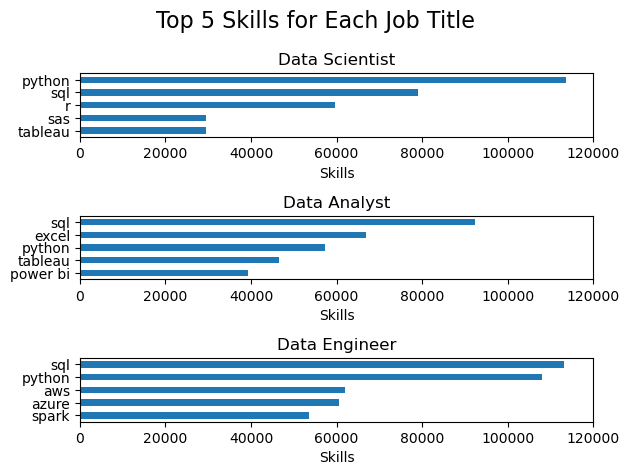

In [75]:
fig, ax = plt.subplots(3,1)

for i,job_titles in enumerate(job_titles):
    job_skills = df_skills_count[df_skills_count['job_title_short'] == job_titles].head()
    job_skills.plot(kind='barh', x='job_skills', y='skill_count', ax=ax[i], legend=False)
    ax[i].set_title(job_titles)
    ax[i].set_xlabel('Skills')
    ax[i].set_ylabel('')
    ax[i].invert_yaxis()
    ax[i].set_xlim(0,120000)
    
fig.suptitle('Top 5 Skills for Each Job Title', fontsize=16)
fig.tight_layout()